In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

In [71]:
# Load Data
df = pd.read_csv('../arthur_hf_scraping/jpm/jpm_funds_returns.csv', index_col=0, parse_dates=True)

# Train/Test Split
train_start = '2020-01-01'
train_end = '2022-12-31'
test_start = '2023-01-01'
test_end = '2026-12-31'

print(f"- Number of funds in the dataset originally: {len(df.columns)}")
print(f"- Number of funds that have a full history during train and test: {df.loc[train_start:test_end].dropna(axis=1, how='any').shape[1]}")

df_train = df.loc[train_start:train_end].dropna(axis=1, how='any')
df_test = df.loc[test_start:test_end]


- Number of funds in the dataset originally: 837
- Number of funds that have a full history during train and test: 239


In [72]:
# Selection Criteria
vol = df_train.std() * np.sqrt(12)
ret = df_train.mean()

# Top 35% of volatility (quantile 0.65 means we want the highest 35%)
vol_threshold = vol.quantile(0.65)
high_vol_funds = vol[vol >= vol_threshold].index

# Filter returns for high vol funds
ret_filtered = ret.loc[high_vol_funds]

# Top 50% of returns among high vol funds
ret_threshold = ret_filtered.quantile(0.50)
final_funds = ret_filtered[ret_filtered >= ret_threshold].index.tolist()

print(f"- Number of funds selected as our 'top funds': {len(final_funds)}")

# Filter test set
test_data = df_test[final_funds].dropna(axis=1, how='any')
print(f"Test data shape: {test_data.shape}")


- Number of funds selected as our 'top funds': 78
Test data shape: (39, 42)


Simulating Portfolios (N=10): 100%|██████████| 5000/5000 [00:02<00:00, 2363.63it/s]


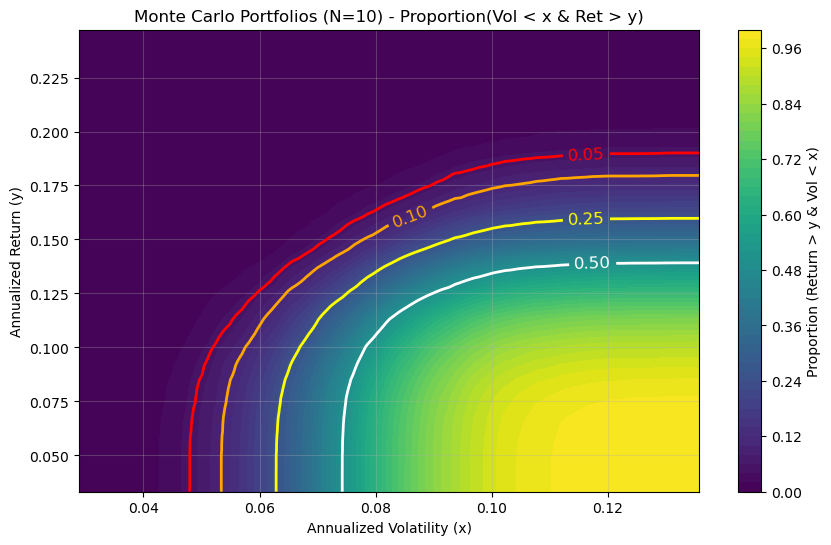

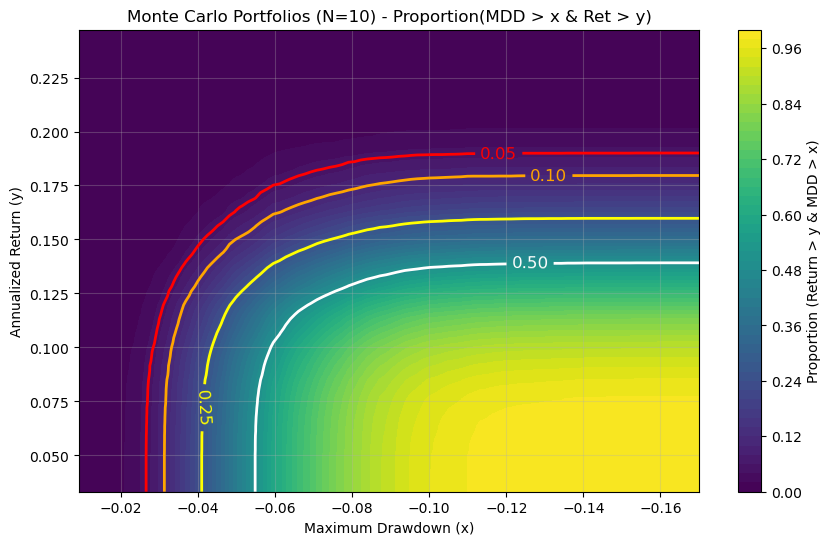

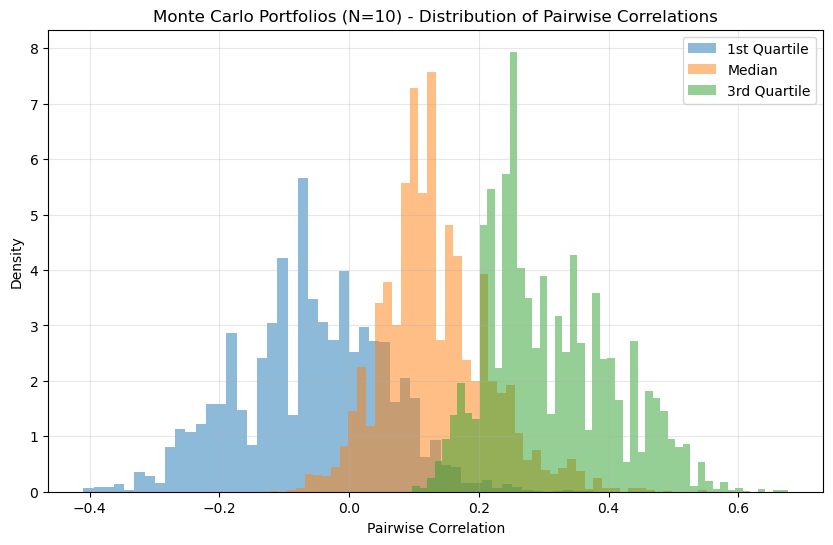

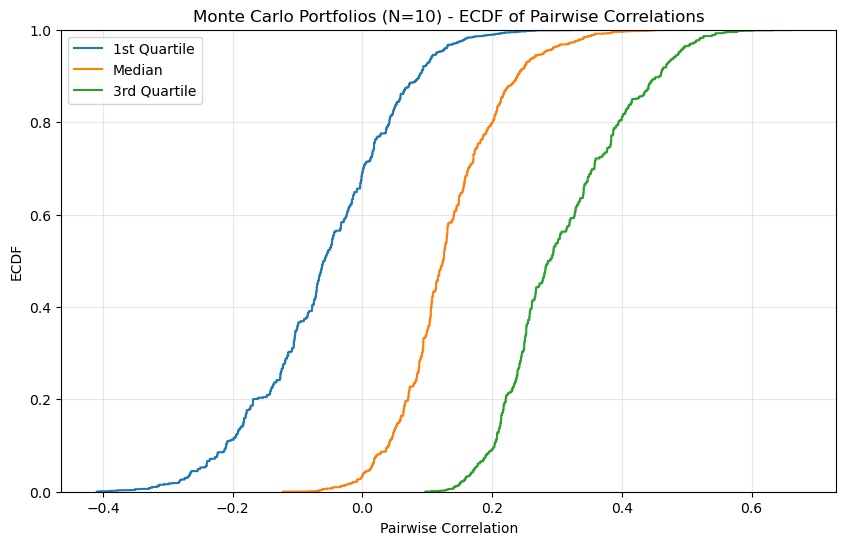

Simulating Portfolios (N=15): 100%|██████████| 5000/5000 [00:02<00:00, 2228.15it/s]


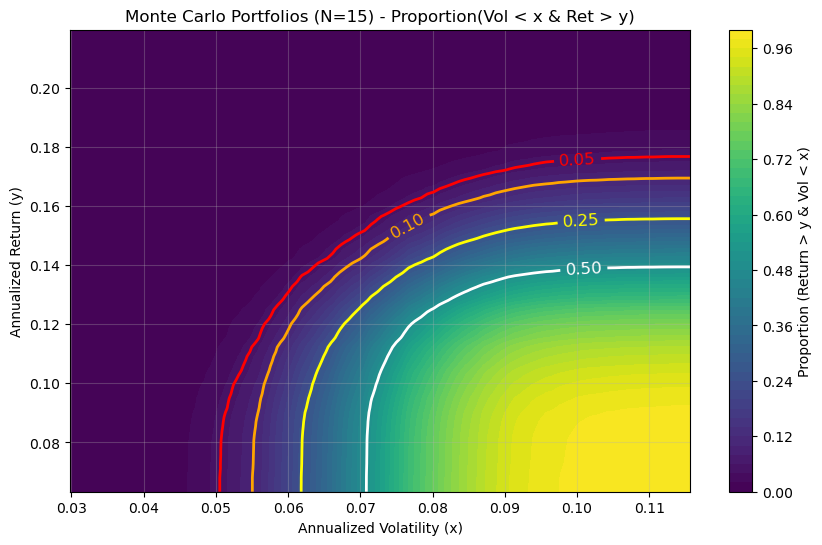

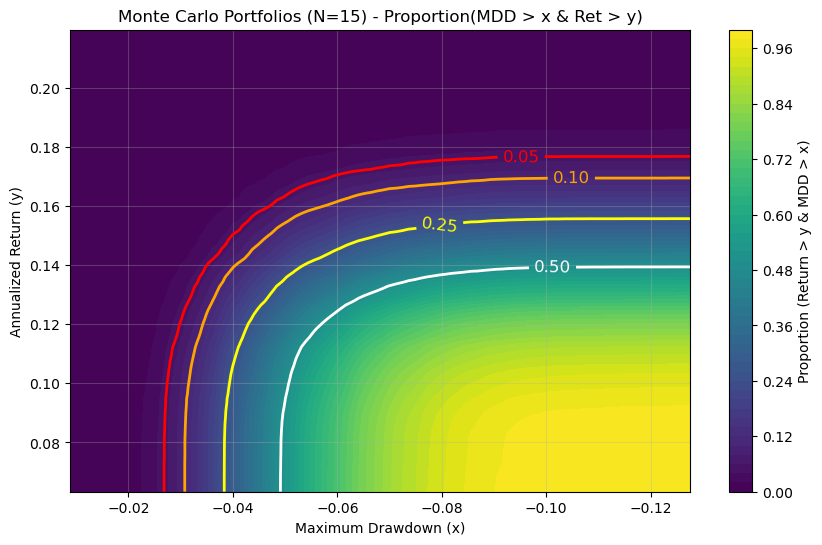

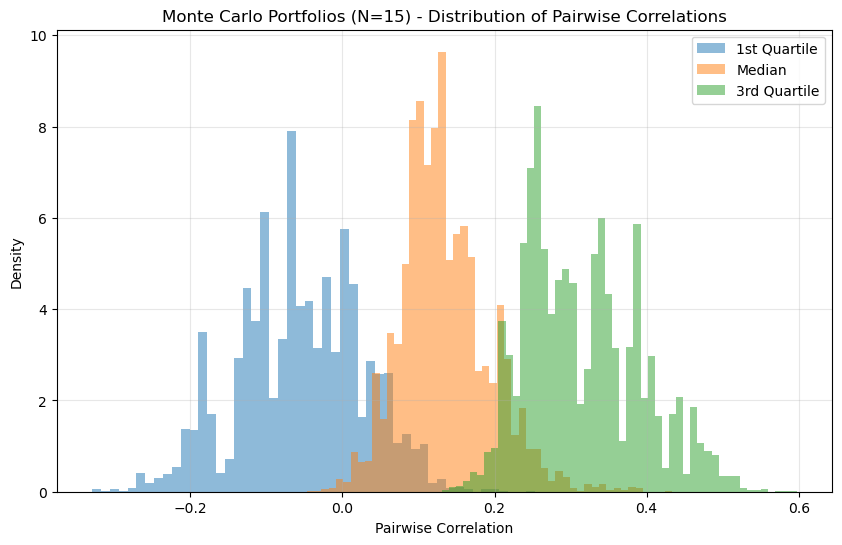

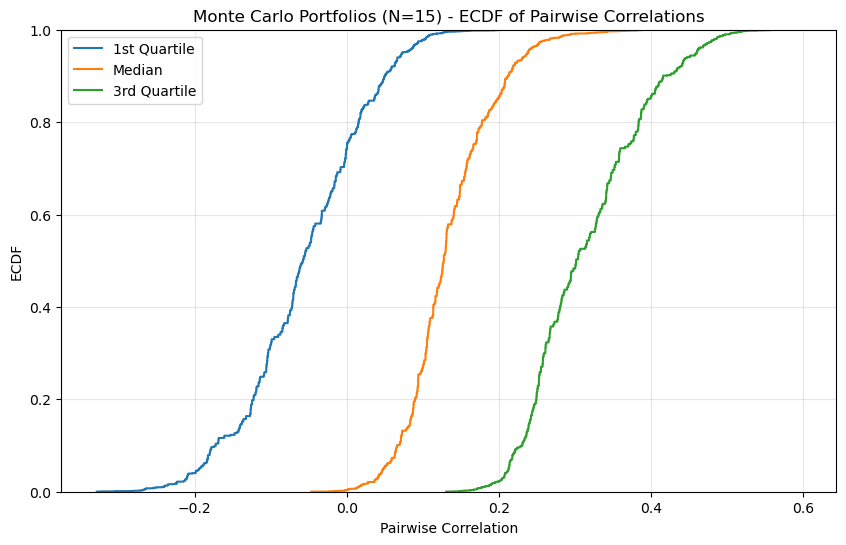

Simulating Portfolios (N=20): 100%|██████████| 5000/5000 [00:02<00:00, 2245.72it/s]


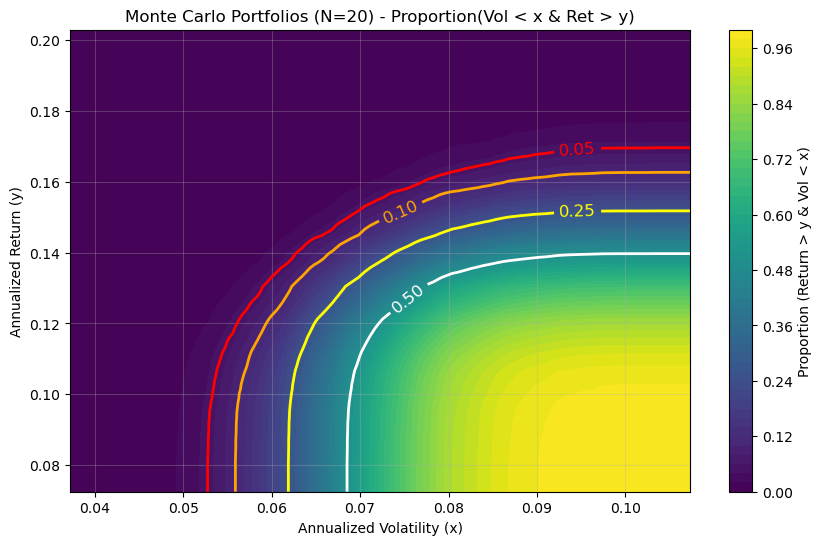

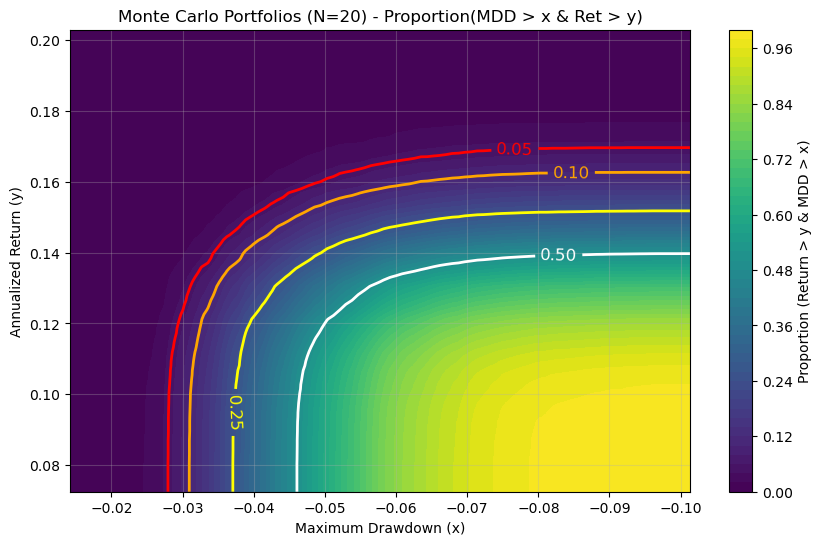

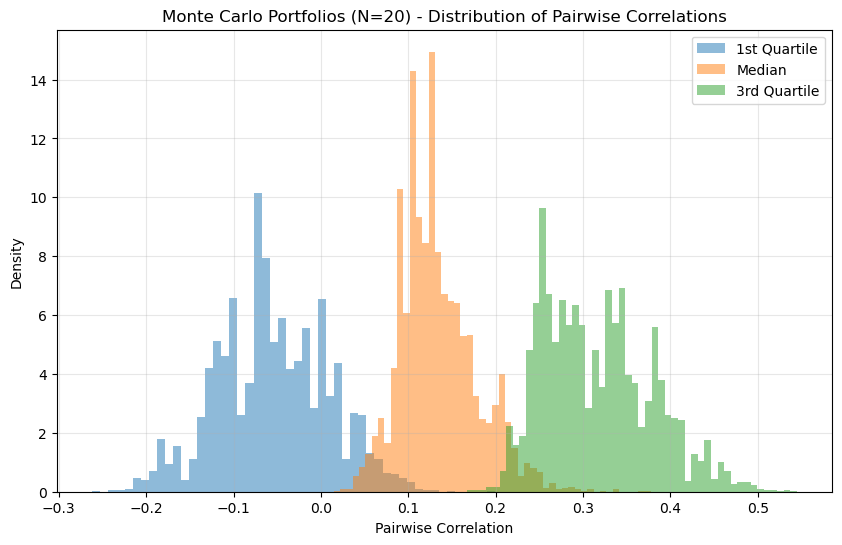

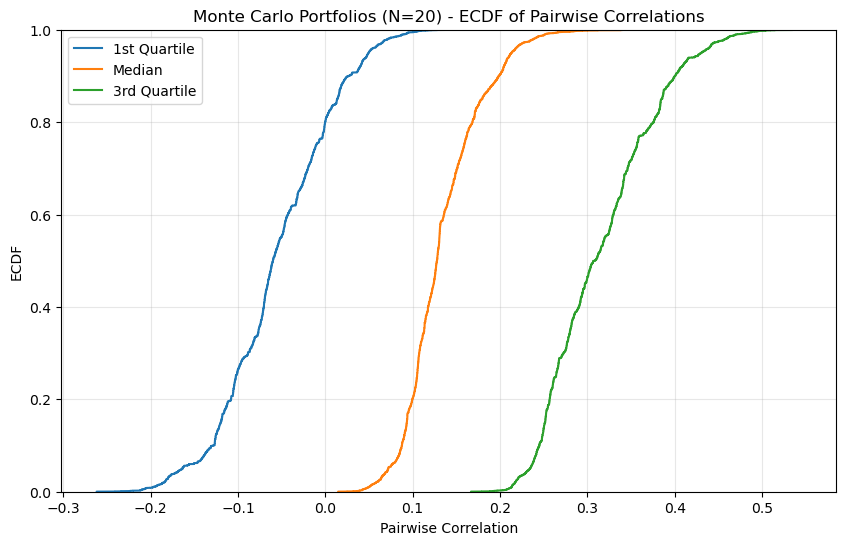

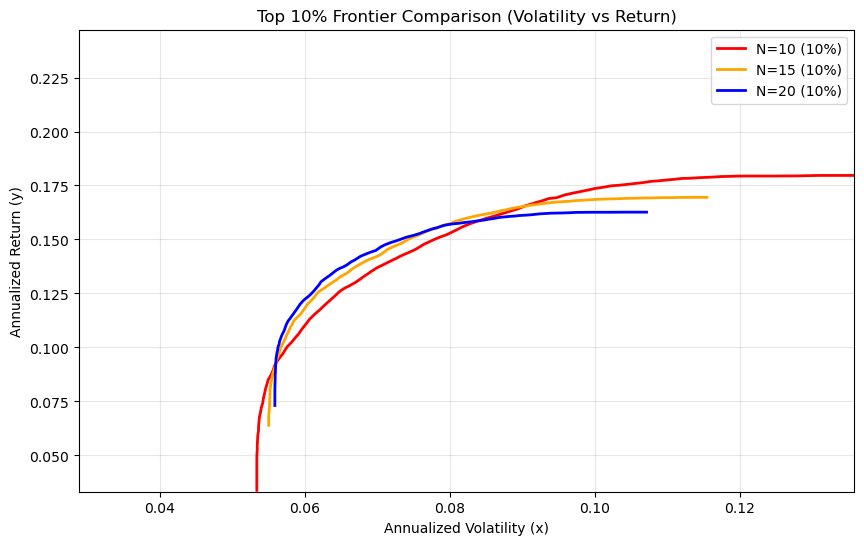

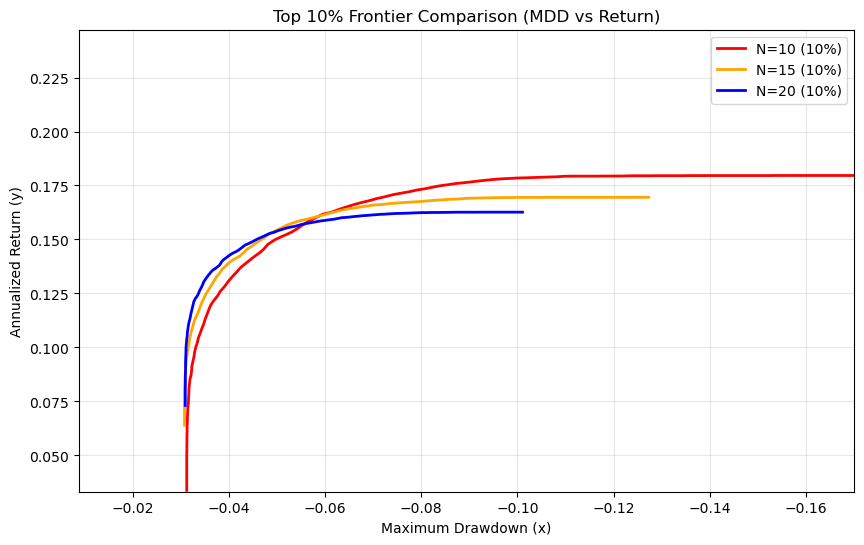

In [73]:
# Monte Carlo Heatmaps for N in [10, 15, 20]
def calculate_mdd(returns):
    cum_ret = (1 + returns).cumprod()
    running_max = cum_ret.cummax()
    drawdown = (cum_ret - running_max) / running_max
    return drawdown.min()

N_heatmap_values = [10, 15, 20]
n_simulations = 5000

np.random.seed(42)
available_funds = test_data.columns.tolist()

# Pre-compute the full correlation matrix to speed up simulations
full_corr_matrix = test_data[available_funds].corr()

# Dictionaries to store the grids for the final overlay plot
vol_grids = {}
mdd_grids = {}

for N in N_heatmap_values:
    if len(available_funds) < N:
        print(f"Not enough funds to simulate N={N}.")
        continue
        
    sim_returns = []
    sim_vols = []
    sim_mdds = []
    sim_corr_q1 = []
    sim_corr_med = []
    sim_corr_q3 = []
    
    for _ in tqdm(range(n_simulations), desc=f'Simulating Portfolios (N={N})'):
        selected_funds = np.random.choice(available_funds, size=N, replace=False)
        portfolio_returns = test_data[selected_funds].mean(axis=1) # Equal Weight
        
        ann_ret = portfolio_returns.mean() * 12
        ann_vol = portfolio_returns.std() * np.sqrt(12)
        mdd = calculate_mdd(portfolio_returns)
        
        # Calculate pairwise correlations
        sub_corr = full_corr_matrix.loc[selected_funds, selected_funds].values
        i, j = np.triu_indices(N, k=1)
        pairwise_corrs = sub_corr[i, j]
        q1, med, q3 = np.percentile(pairwise_corrs, [25, 50, 75])
        
        sim_returns.append(ann_ret)
        sim_vols.append(ann_vol)
        sim_mdds.append(mdd)
        sim_corr_q1.append(q1)
        sim_corr_med.append(med)
        sim_corr_q3.append(q3)

    sim_returns_arr = np.array(sim_returns)
    sim_vols_arr = np.array(sim_vols)
    sim_mdds_arr = np.array(sim_mdds)
    sim_corr_q1_arr = np.array(sim_corr_q1)
    sim_corr_med_arr = np.array(sim_corr_med)
    sim_corr_q3_arr = np.array(sim_corr_q3)
    
    # --- Plot 1: Return vs Volatility ---
    ret_min, ret_max = np.min(sim_returns_arr), np.max(sim_returns_arr)
    vol_min, vol_max = np.min(sim_vols_arr), np.max(sim_vols_arr)
    
    x_grid = np.linspace(ret_min, ret_max, 100)
    y_grid_vol = np.linspace(vol_min, vol_max, 100)
    X_vol, Y_vol = np.meshgrid(y_grid_vol, x_grid)
    Z_vol = np.zeros_like(X_vol)
    
    for i in range(X_vol.shape[0]):
        for j in range(X_vol.shape[1]):
            x = X_vol[i, j]
            y = Y_vol[i, j]
            prop = np.sum((sim_returns_arr > y) & (sim_vols_arr < x)) / n_simulations
            Z_vol[i, j] = prop
            
    vol_grids[N] = (X_vol, Y_vol, Z_vol)

    plt.figure(figsize=(10, 6))
    c1 = plt.contourf(X_vol, Y_vol, Z_vol, levels=50, cmap='viridis')
    plt.colorbar(c1, label='Proportion (Return > y & Vol < x)')
    
    cs1 = plt.contour(X_vol, Y_vol, Z_vol, levels=[0.05, 0.10, 0.25, 0.50], colors=['red', 'orange', 'yellow', 'white'], linewidths=2)
    plt.clabel(cs1, inline=True, fontsize=12, fmt='%.2f')

    plt.title(f'Monte Carlo Portfolios (N={N}) - Proportion(Vol < x & Ret > y)')
    plt.xlabel('Annualized Volatility (x)')
    plt.ylabel('Annualized Return (y)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # --- Plot 2: Return vs MDD ---
    mdd_min, mdd_max = np.min(sim_mdds_arr), np.max(sim_mdds_arr)
    
    y_grid_mdd = np.linspace(mdd_min, mdd_max, 100)
    X_mdd, Y_mdd = np.meshgrid(y_grid_mdd, x_grid)
    Z_mdd = np.zeros_like(X_mdd)
    
    for i in range(X_mdd.shape[0]):
        for j in range(X_mdd.shape[1]):
            x = X_mdd[i, j]
            y = Y_mdd[i, j]
            prop = np.sum((sim_returns_arr > y) & (sim_mdds_arr > x)) / n_simulations
            Z_mdd[i, j] = prop
            
    mdd_grids[N] = (X_mdd, Y_mdd, Z_mdd)

    plt.figure(figsize=(10, 6))
    c2 = plt.contourf(X_mdd, Y_mdd, Z_mdd, levels=50, cmap='viridis')
    plt.colorbar(c2, label='Proportion (Return > y & MDD > x)')
    
    cs2 = plt.contour(X_mdd, Y_mdd, Z_mdd, levels=[0.05, 0.10, 0.25, 0.50], colors=['red', 'orange', 'yellow', 'white'], linewidths=2)
    plt.clabel(cs2, inline=True, fontsize=12, fmt='%.2f')

    plt.title(f'Monte Carlo Portfolios (N={N}) - Proportion(MDD > x & Ret > y)')
    plt.xlabel('Maximum Drawdown (x)')
    plt.ylabel('Annualized Return (y)')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_xaxis()
    plt.show()

    # --- Plot 3: Distribution of Pairwise Correlations ---
    plt.figure(figsize=(10, 6))
    plt.hist(sim_corr_q1_arr, bins=50, alpha=0.5, density=True, label='1st Quartile')
    plt.hist(sim_corr_med_arr, bins=50, alpha=0.5, density=True, label='Median')
    plt.hist(sim_corr_q3_arr, bins=50, alpha=0.5, density=True, label='3rd Quartile')
    plt.title(f'Monte Carlo Portfolios (N={N}) - Distribution of Pairwise Correlations')
    plt.xlabel('Pairwise Correlation')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- Plot 4: ECDF of Pairwise Correlations ---
    plt.figure(figsize=(10, 6))
    sns.ecdfplot(sim_corr_q1_arr, label="1st Quartile")
    sns.ecdfplot(sim_corr_med_arr, label="Median")
    sns.ecdfplot(sim_corr_q3_arr, label="3rd Quartile")
    plt.title(f"Monte Carlo Portfolios (N={N}) - ECDF of Pairwise Correlations")
    plt.xlabel("Pairwise Correlation")
    plt.ylabel("ECDF")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Final Overlay Plots for Top x% ---
x = 10
if len(vol_grids) > 0:
    plt.figure(figsize=(10, 6))
    colors = {10: 'red', 15: 'orange', 20: 'blue'}
    
    for N, (X_vol, Y_vol, Z_vol) in vol_grids.items():
        cs = plt.contour(X_vol, Y_vol, Z_vol, levels=[x/100], colors=[colors[N]], linewidths=2)
        # dummy line for legend
        plt.plot([], [], color=colors[N], linewidth=2, label=f'N={N} ({x}%)')
        
    plt.title(f'Top {x}% Frontier Comparison (Volatility vs Return)')
    plt.xlabel('Annualized Volatility (x)')
    plt.ylabel('Annualized Return (y)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if len(mdd_grids) > 0:
    plt.figure(figsize=(10, 6))
    colors = {10: 'red', 15: 'orange', 20: 'blue'}
    
    for N, (X_mdd, Y_mdd, Z_mdd) in mdd_grids.items():
        cs = plt.contour(X_mdd, Y_mdd, Z_mdd, levels=[x/100], colors=[colors[N]], linewidths=2)
        plt.plot([], [], color=colors[N], linewidth=2, label=f'N={N} ({x}%)')
        
    plt.title(f'Top {x}% Frontier Comparison (MDD vs Return)')
    plt.xlabel('Maximum Drawdown (x)')
    plt.ylabel('Annualized Return (y)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().invert_xaxis()
    plt.show()


In [74]:
# Monte Carlo metrics vs N
def calculate_cagr(returns):
    cum_ret = (1 + returns).prod()
    n_years = len(returns) / 12
    return ((cum_ret ** (1 / n_years) - 1) * 100) if n_years > 0 else np.nan

def calculate_max_drawdown_duration(returns):
    cum_ret = (1 + returns).cumprod()
    running_max = cum_ret.cummax()
    is_high = (cum_ret == running_max)
    high_indices = np.where(is_high)[0]
    
    if len(high_indices) == 0:
        return len(returns)
        
    durations = np.diff(high_indices)
    last_duration = len(returns) - 1 - high_indices[-1]
    
    if len(durations) > 0:
        max_duration = max(durations.max(), last_duration)
    else:
        max_duration = last_duration
        
    return max_duration

N_values = [2, 4, 6, 8, 10, 15, 20, 25, 30]
n_sim_per_n = 1000

stats = {
    'mdd': {'N': [], 'median': [], 'q1': [], 'q3': []},
    'calmar': {'N': [], 'median': [], 'q1': [], 'q3': []},
    'vol': {'N': [], 'median': [], 'q1': [], 'q3': []},
    'sharpe': {'N': [], 'median': [], 'q1': [], 'q3': []},
    'duration': {'N': [], 'median': [], 'q1': [], 'q3': []},
    'cagr': {'N': [], 'median': [], 'q1': [], 'q3': []}
}

for n in tqdm(N_values, desc='Testing various N'):
    if n > len(available_funds):
        continue
    
    mdds, calmars, vols, sharpes, durations, cagrs = [], [], [], [], [], []
    for _ in range(n_sim_per_n):
        selected_funds = np.random.choice(available_funds, size=n, replace=False)
        portfolio_returns = test_data[selected_funds].mean(axis=1)
        
        # Calculate metrics
        mdd = calculate_mdd(portfolio_returns)
        cagr = calculate_cagr(portfolio_returns)
        calmar = (cagr / 100) / abs(mdd) if mdd != 0 else np.nan
        
        vol = portfolio_returns.std() * np.sqrt(12)
        sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * np.sqrt(12) if portfolio_returns.std() != 0 else np.nan
        duration = calculate_max_drawdown_duration(portfolio_returns)
        
        mdds.append(mdd)
        calmars.append(calmar)
        vols.append(vol)
        sharpes.append(sharpe)
        durations.append(duration)
        cagrs.append(cagr)
        
    for key, arr in zip(['mdd', 'calmar', 'vol', 'sharpe', 'duration', 'cagr'], [mdds, calmars, vols, sharpes, durations, cagrs]):
        stats[key]['N'].append(n)
        stats[key]['median'].append(np.nanmedian(arr))
        stats[key]['q1'].append(np.nanpercentile(arr, 25))
        stats[key]['q3'].append(np.nanpercentile(arr, 75))


Testing various N: 100%|██████████| 9/9 [00:03<00:00,  2.57it/s]


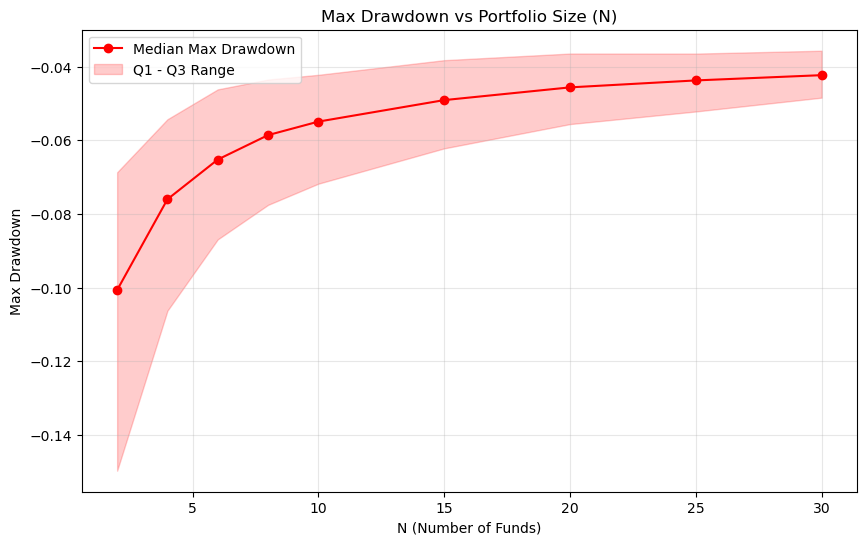

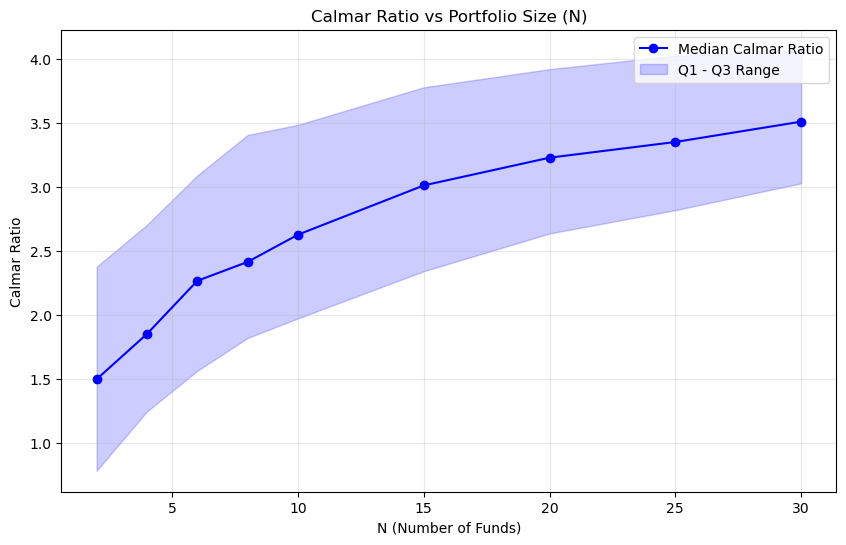

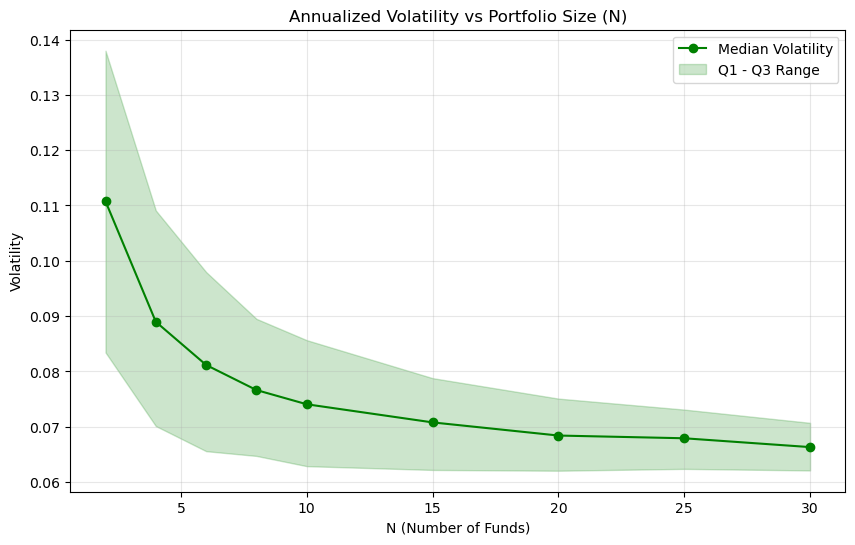

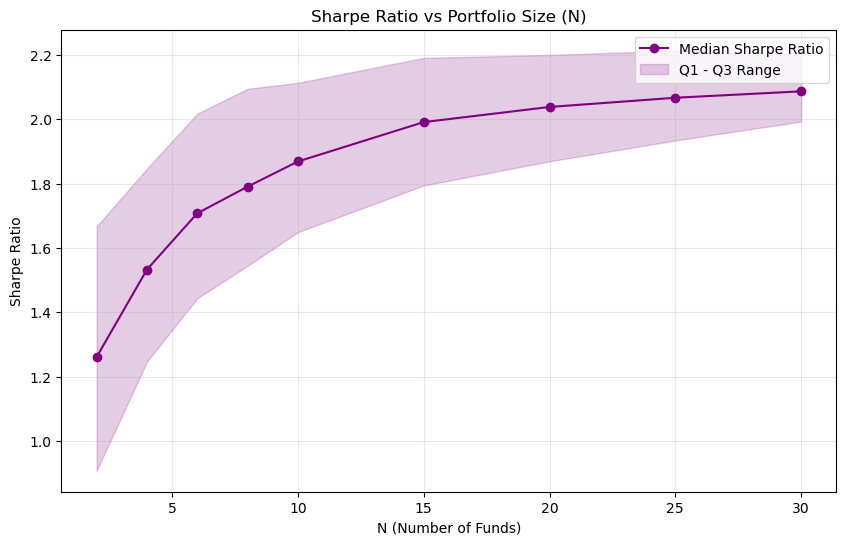

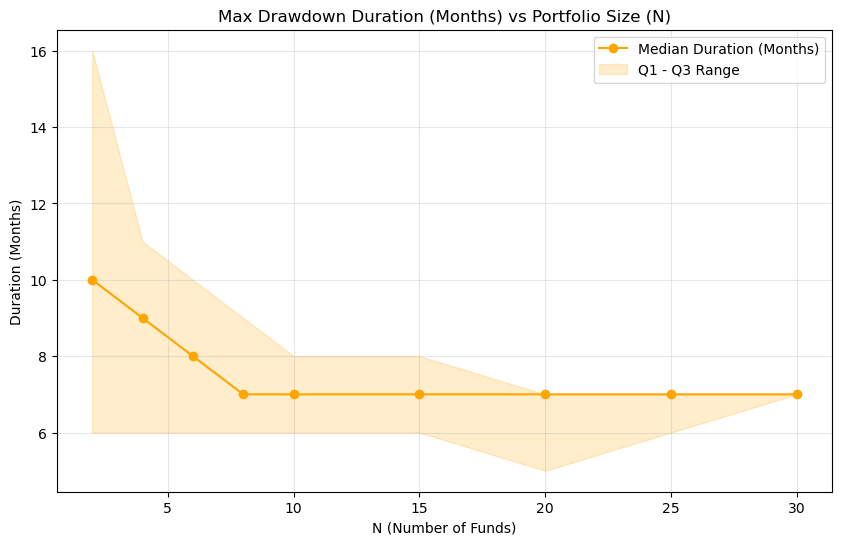

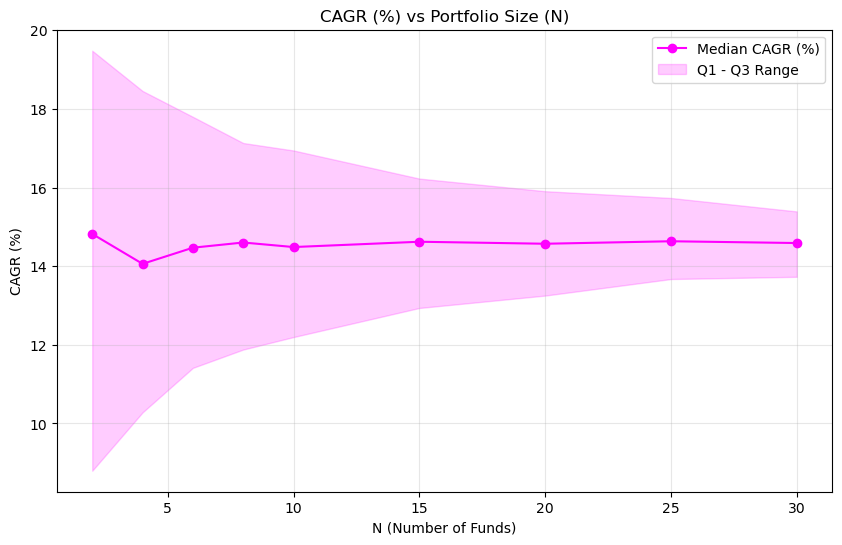

In [75]:
# Plotting Metrics vs N
if len(stats['mdd']['N']) > 0:
    metrics_info = [
        ('mdd', 'Max Drawdown vs Portfolio Size (N)', 'Max Drawdown', 'red'),
        ('calmar', 'Calmar Ratio vs Portfolio Size (N)', 'Calmar Ratio', 'blue'),
        ('vol', 'Annualized Volatility vs Portfolio Size (N)', 'Volatility', 'green'),
        ('sharpe', 'Sharpe Ratio vs Portfolio Size (N)', 'Sharpe Ratio', 'purple'),
        ('duration', 'Max Drawdown Duration (Months) vs Portfolio Size (N)', 'Duration (Months)', 'orange'),
        ('cagr', 'CAGR (%) vs Portfolio Size (N)', 'CAGR (%)', 'magenta')
    ]
    
    for key, title, ylabel, color in metrics_info:
        plt.figure(figsize=(10, 6))
        plt.plot(stats[key]['N'], stats[key]['median'], marker='o', label=f'Median {ylabel}', color=color)
        plt.fill_between(stats[key]['N'], stats[key]['q1'], stats[key]['q3'], color=color, alpha=0.2, label='Q1 - Q3 Range')
        plt.title(title)
        plt.xlabel('N (Number of Funds)')
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

else:
    print("Not enough funds for testing N_values.")


## Filtered Analysis: 3rd Quartile Train Correlation < Treshold
The following cells repeat the Monte Carlo analysis but only select portfolios where the 3rd quartile of pairwise correlation on the train set is less than 0.3.

Simulating Portfolios (N=10): 100%|██████████| 5000/5000 [00:01<00:00, 4207.22it/s]


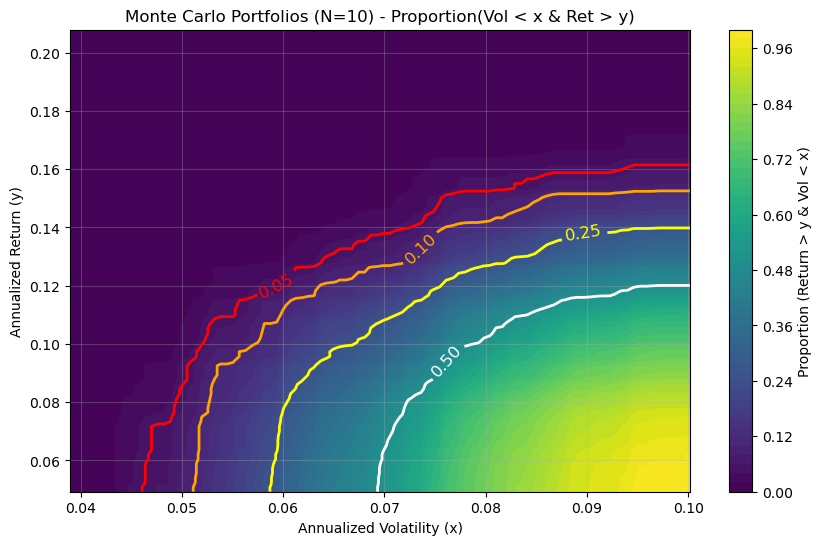

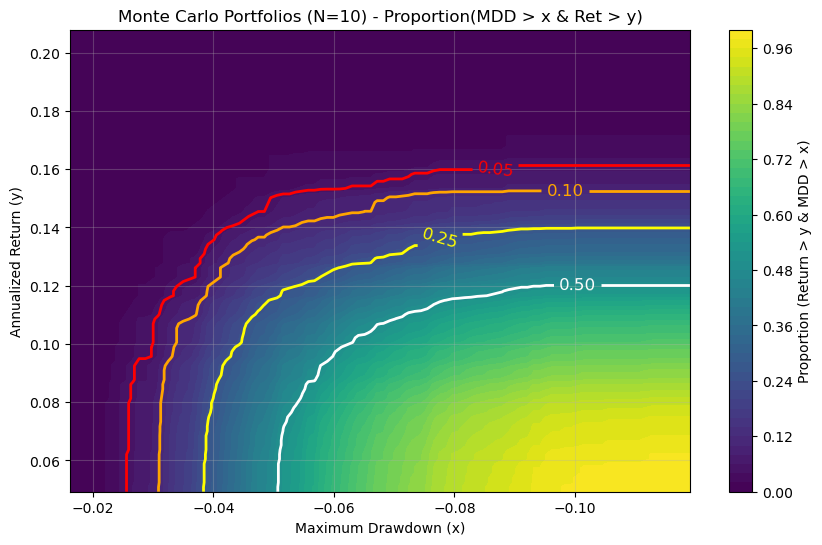

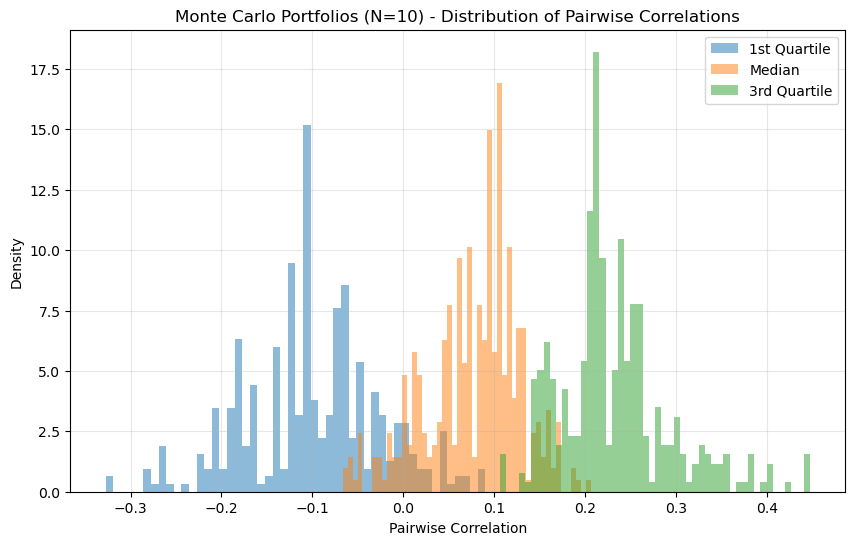

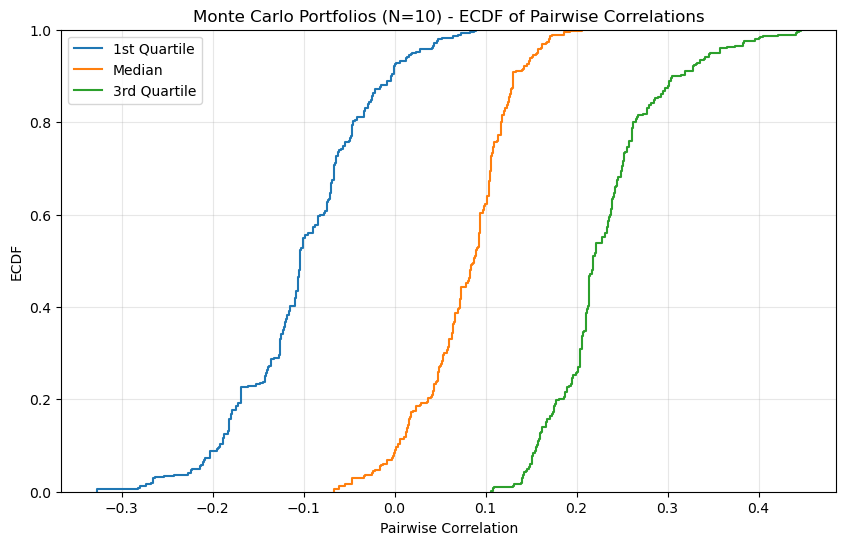

Simulating Portfolios (N=15): 100%|██████████| 5000/5000 [00:00<00:00, 5301.64it/s]


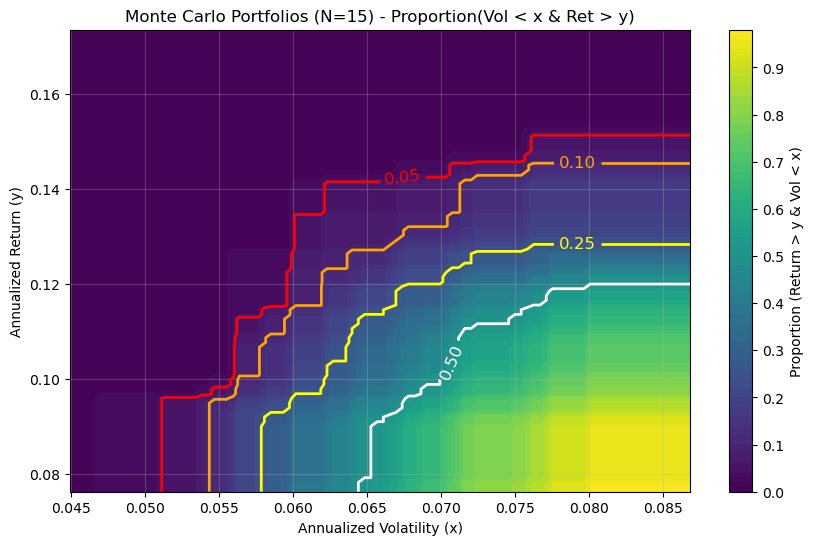

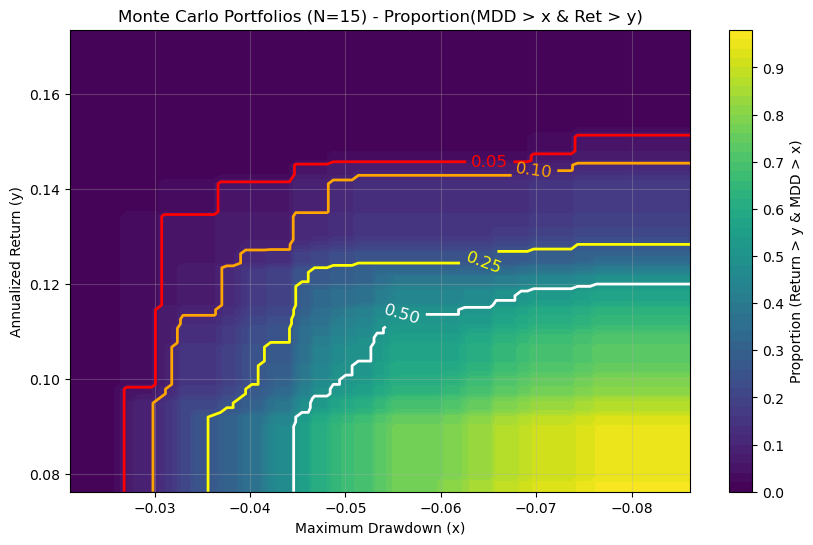

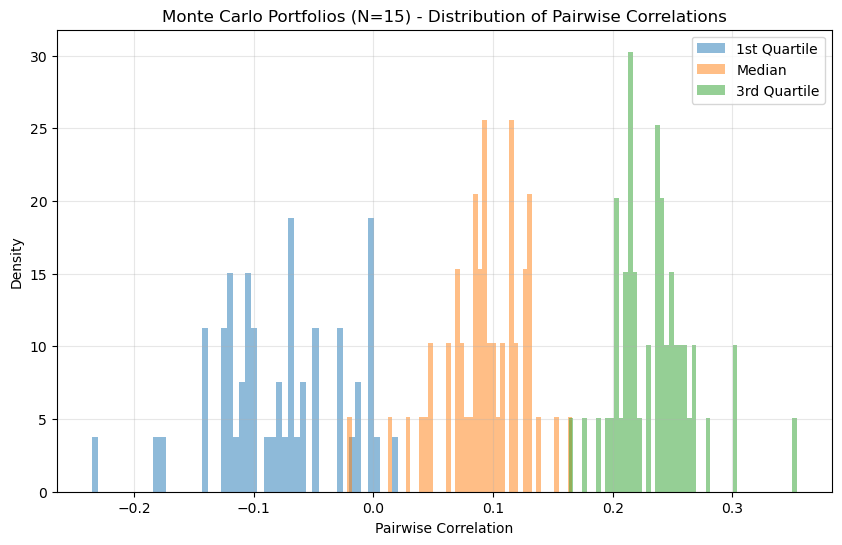

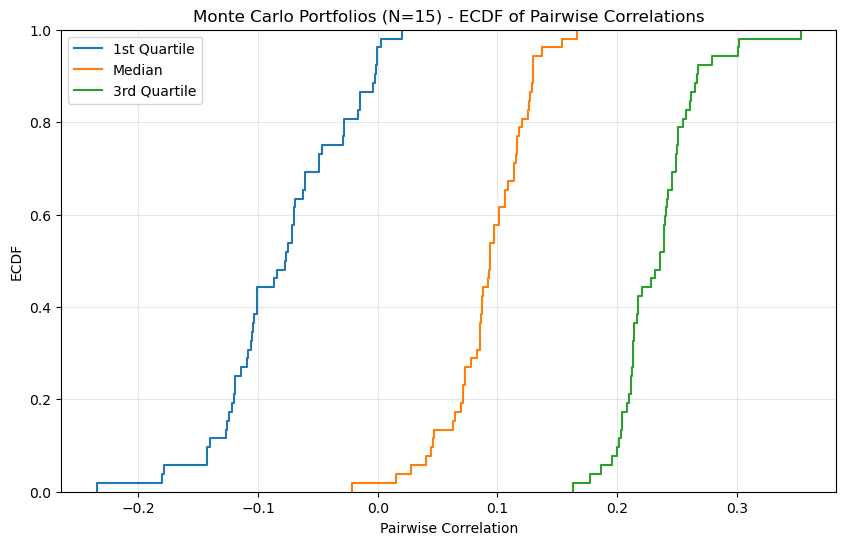

Simulating Portfolios (N=20): 100%|██████████| 5000/5000 [00:00<00:00, 5411.19it/s]


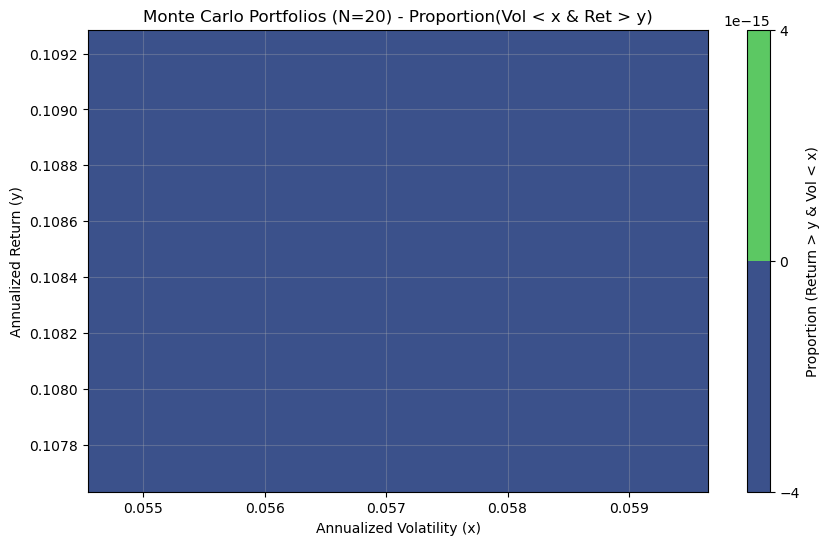

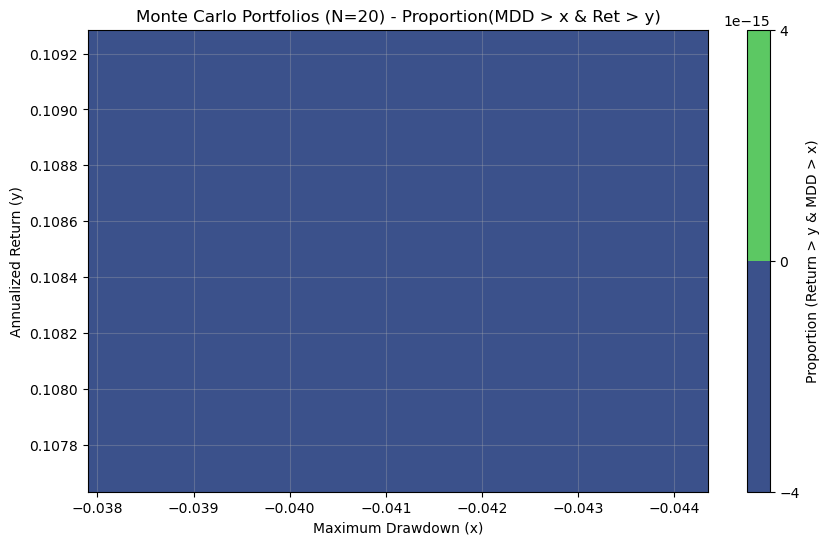

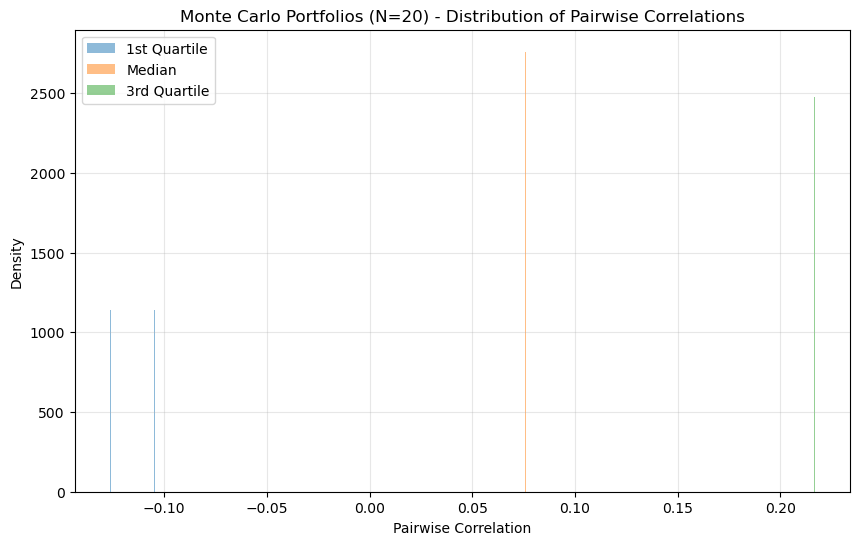

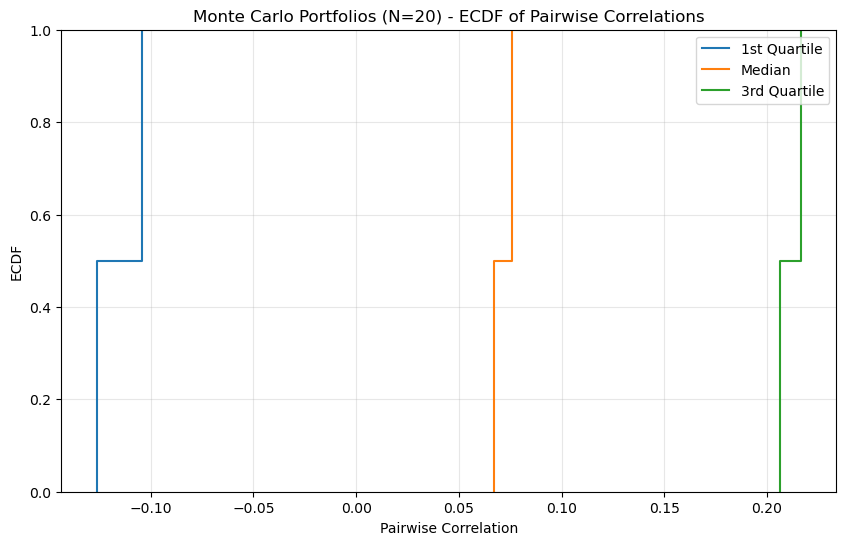

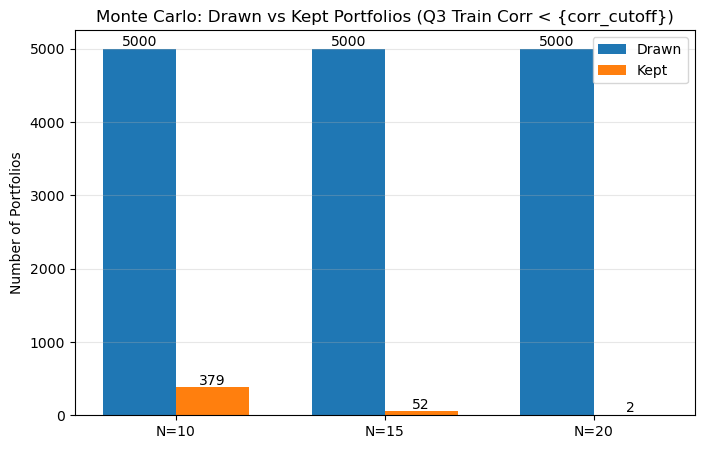

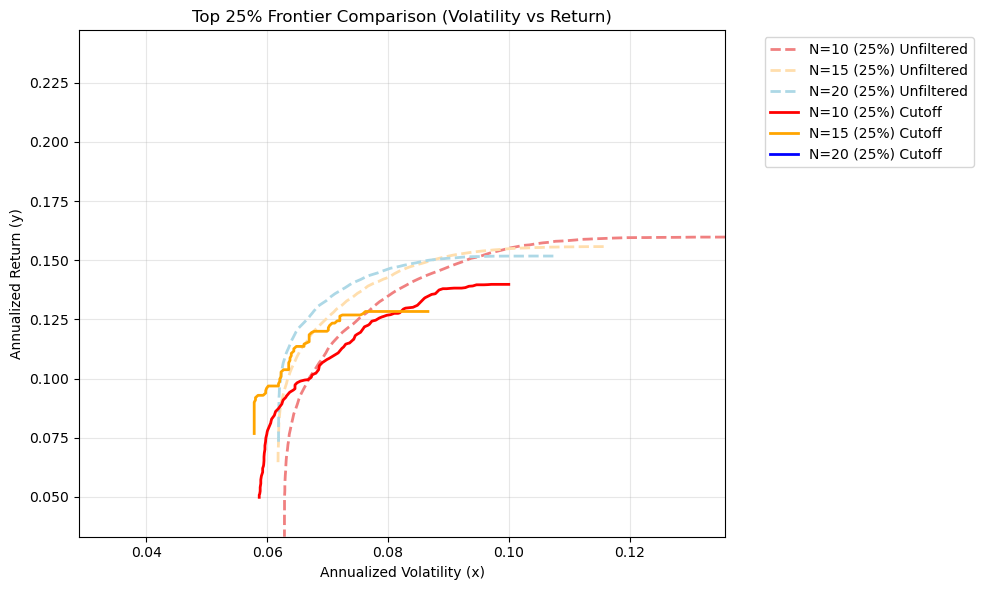

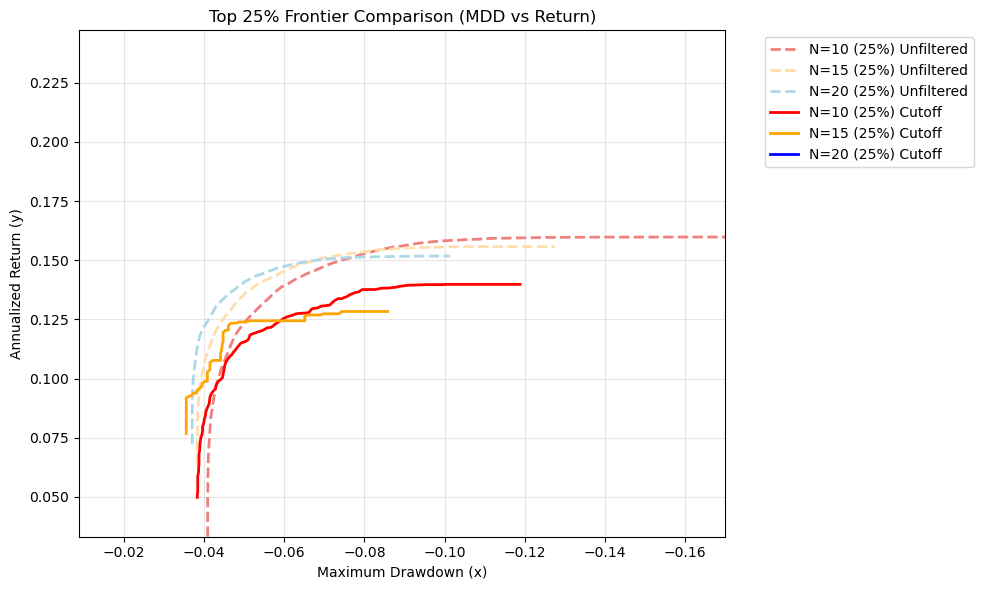

In [76]:
# Filtered Monte Carlo Heatmaps (Q3 Train Correlation < 0.3)
def calculate_mdd(returns):
    cum_ret = (1 + returns).cumprod()
    running_max = cum_ret.cummax()
    drawdown = (cum_ret - running_max) / running_max
    return drawdown.min()

N_heatmap_values = [10, 15, 20]
n_simulations = 5000

corr_cutoff = 0.3
np.random.seed(42)
available_funds = test_data.columns.tolist()

# Define train_data to match available funds and compute correlation matrices
train_data = df_train[available_funds]
train_corr_matrix = train_data.corr()
full_corr_matrix = test_data[available_funds].corr()

# Dictionaries to store the grids for the final overlay plot
vol_grids_cut = {}
mdd_grids_cut = {}

drawn_counts = []
kept_counts = []

for N in N_heatmap_values:
    if len(available_funds) < N:
        print(f"Not enough funds to simulate N={N}.")
        continue
        
    sim_returns = []
    sim_vols = []
    sim_mdds = []
    sim_corr_q1 = []
    sim_corr_med = []
    sim_corr_q3 = []
    
    kept = 0
    drawn = n_simulations
    
    for _ in tqdm(range(n_simulations), desc=f'Simulating Portfolios (N={N})'):
        selected_funds = np.random.choice(available_funds, size=N, replace=False)
        
        # Check condition on train set (Q3 correlation < 0.3)
        train_sub_corr = train_corr_matrix.loc[selected_funds, selected_funds].values
        i, j = np.triu_indices(N, k=1)
        train_pairwise = train_sub_corr[i, j]
        train_q3 = np.percentile(train_pairwise, 75)
        
        if train_q3 >= corr_cutoff:
            continue
            
        kept += 1
        
        portfolio_returns = test_data[selected_funds].mean(axis=1) # Equal Weight
        
        ann_ret = portfolio_returns.mean() * 12
        ann_vol = portfolio_returns.std() * np.sqrt(12)
        mdd = calculate_mdd(portfolio_returns)
        
        # Calculate pairwise correlations on test set
        sub_corr = full_corr_matrix.loc[selected_funds, selected_funds].values
        pairwise_corrs = sub_corr[i, j]
        q1, med, q3 = np.percentile(pairwise_corrs, [25, 50, 75])
        
        sim_returns.append(ann_ret)
        sim_vols.append(ann_vol)
        sim_mdds.append(mdd)
        sim_corr_q1.append(q1)
        sim_corr_med.append(med)
        sim_corr_q3.append(q3)

    drawn_counts.append(drawn)
    kept_counts.append(kept)
    
    if kept == 0:
        print(f"No portfolios kept for N={N} (all Q3 train corrs >= {corr_cutoff})")
        continue

    sim_returns_arr = np.array(sim_returns)
    sim_vols_arr = np.array(sim_vols)
    sim_mdds_arr = np.array(sim_mdds)
    sim_corr_q1_arr = np.array(sim_corr_q1)
    sim_corr_med_arr = np.array(sim_corr_med)
    sim_corr_q3_arr = np.array(sim_corr_q3)
    
    # --- Plot 1: Return vs Volatility ---
    ret_min, ret_max = np.min(sim_returns_arr), np.max(sim_returns_arr)
    vol_min, vol_max = np.min(sim_vols_arr), np.max(sim_vols_arr)
    
    x_grid = np.linspace(ret_min, ret_max, 100)
    y_grid_vol = np.linspace(vol_min, vol_max, 100)
    X_vol, Y_vol = np.meshgrid(y_grid_vol, x_grid)
    Z_vol = np.zeros_like(X_vol)
    
    for i in range(X_vol.shape[0]):
        for j in range(X_vol.shape[1]):
            x = X_vol[i, j]
            y = Y_vol[i, j]
            prop = np.sum((sim_returns_arr > y) & (sim_vols_arr < x)) / kept
            Z_vol[i, j] = prop
            
    vol_grids_cut[N] = (X_vol, Y_vol, Z_vol)

    plt.figure(figsize=(10, 6))
    c1 = plt.contourf(X_vol, Y_vol, Z_vol, levels=50, cmap='viridis')
    plt.colorbar(c1, label='Proportion (Return > y & Vol < x)')
    
    cs1 = plt.contour(X_vol, Y_vol, Z_vol, levels=[0.05, 0.10, 0.25, 0.50], colors=['red', 'orange', 'yellow', 'white'], linewidths=2)
    plt.clabel(cs1, inline=True, fontsize=12, fmt='%.2f')

    plt.title(f'Monte Carlo Portfolios (N={N}) - Proportion(Vol < x & Ret > y)')
    plt.xlabel('Annualized Volatility (x)')
    plt.ylabel('Annualized Return (y)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # --- Plot 2: Return vs MDD ---
    mdd_min, mdd_max = np.min(sim_mdds_arr), np.max(sim_mdds_arr)
    
    y_grid_mdd = np.linspace(mdd_min, mdd_max, 100)
    X_mdd, Y_mdd = np.meshgrid(y_grid_mdd, x_grid)
    Z_mdd = np.zeros_like(X_mdd)
    
    for i in range(X_mdd.shape[0]):
        for j in range(X_mdd.shape[1]):
            x = X_mdd[i, j]
            y = Y_mdd[i, j]
            prop = np.sum((sim_returns_arr > y) & (sim_mdds_arr > x)) / kept
            Z_mdd[i, j] = prop
            
    mdd_grids_cut[N] = (X_mdd, Y_mdd, Z_mdd)

    plt.figure(figsize=(10, 6))
    c2 = plt.contourf(X_mdd, Y_mdd, Z_mdd, levels=50, cmap='viridis')
    plt.colorbar(c2, label='Proportion (Return > y & MDD > x)')
    
    cs2 = plt.contour(X_mdd, Y_mdd, Z_mdd, levels=[0.05, 0.10, 0.25, 0.50], colors=['red', 'orange', 'yellow', 'white'], linewidths=2)
    plt.clabel(cs2, inline=True, fontsize=12, fmt='%.2f')

    plt.title(f'Monte Carlo Portfolios (N={N}) - Proportion(MDD > x & Ret > y)')
    plt.xlabel('Maximum Drawdown (x)')
    plt.ylabel('Annualized Return (y)')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_xaxis()
    plt.show()

    # --- Plot 3: Distribution of Pairwise Correlations ---
    plt.figure(figsize=(10, 6))
    plt.hist(sim_corr_q1_arr, bins=50, alpha=0.5, density=True, label='1st Quartile')
    plt.hist(sim_corr_med_arr, bins=50, alpha=0.5, density=True, label='Median')
    plt.hist(sim_corr_q3_arr, bins=50, alpha=0.5, density=True, label='3rd Quartile')
    plt.title(f'Monte Carlo Portfolios (N={N}) - Distribution of Pairwise Correlations')
    plt.xlabel('Pairwise Correlation')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- Plot 4: ECDF of Pairwise Correlations ---
    plt.figure(figsize=(10, 6))
    sns.ecdfplot(sim_corr_q1_arr, label="1st Quartile")
    sns.ecdfplot(sim_corr_med_arr, label="Median")
    sns.ecdfplot(sim_corr_q3_arr, label="3rd Quartile")
    plt.title(f"Monte Carlo Portfolios (N={N}) - ECDF of Pairwise Correlations")
    plt.xlabel("Pairwise Correlation")
    plt.ylabel("ECDF")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Drawn vs Kept Plot ---
plt.figure(figsize=(8, 5))
x_pos = np.arange(len(N_heatmap_values))
width = 0.35
plt.bar(x_pos - width/2, drawn_counts, width, label='Drawn')
plt.bar(x_pos + width/2, kept_counts, width, label='Kept')
plt.xticks(x_pos, [f'N={n}' for n in N_heatmap_values])
plt.title('Monte Carlo: Drawn vs Kept Portfolios (Q3 Train Corr < {corr_cutoff})')
plt.ylabel('Number of Portfolios')
plt.legend()
plt.grid(axis='y', alpha=0.3)
for i, (d, k) in enumerate(zip(drawn_counts, kept_counts)):
    plt.text(i - width/2, d, str(d), ha='center', va='bottom')
    plt.text(i + width/2, k, str(k), ha='center', va='bottom')
plt.show()

# --- Final Overlay Plots for Top x% (Comparison: Cutoff vs Non-Cutoff) ---
x = 25
if len(vol_grids) > 0 and len(vol_grids_cut) > 0:
    plt.figure(figsize=(10, 6))
    colors_uncut = {10: 'lightcoral', 15: 'navajowhite', 20: 'lightblue'}
    colors_cut = {10: 'red', 15: 'orange', 20: 'blue'}
    
    # Plot non-cutoff frontiers
    for N, (X_vol, Y_vol, Z_vol) in vol_grids.items():
        cs = plt.contour(X_vol, Y_vol, Z_vol, levels=[x/100], colors=[colors_uncut[N]], linewidths=2, linestyles='dashed')
        plt.plot([], [], color=colors_uncut[N], linewidth=2, linestyle='dashed', label=f'N={N} ({x}%) Unfiltered')
        
    # Plot cutoff frontiers
    for N, (X_vol, Y_vol, Z_vol) in vol_grids_cut.items():
        cs = plt.contour(X_vol, Y_vol, Z_vol, levels=[x/100], colors=[colors_cut[N]], linewidths=2)
        plt.plot([], [], color=colors_cut[N], linewidth=2, label=f'N={N} ({x}%) Cutoff')
        
    plt.title(f'Top {x}% Frontier Comparison (Volatility vs Return)')
    plt.xlabel('Annualized Volatility (x)')
    plt.ylabel('Annualized Return (y)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if len(mdd_grids) > 0 and len(mdd_grids_cut) > 0:
    plt.figure(figsize=(10, 6))
    colors_uncut = {10: 'lightcoral', 15: 'navajowhite', 20: 'lightblue'}
    colors_cut = {10: 'red', 15: 'orange', 20: 'blue'}
    
    for N, (X_mdd, Y_mdd, Z_mdd) in mdd_grids.items():
        cs = plt.contour(X_mdd, Y_mdd, Z_mdd, levels=[x/100], colors=[colors_uncut[N]], linewidths=2, linestyles='dashed')
        plt.plot([], [], color=colors_uncut[N], linewidth=2, linestyle='dashed', label=f'N={N} ({x}%) Unfiltered')
        
    for N, (X_mdd, Y_mdd, Z_mdd) in mdd_grids_cut.items():
        cs = plt.contour(X_mdd, Y_mdd, Z_mdd, levels=[x/100], colors=[colors_cut[N]], linewidths=2)
        plt.plot([], [], color=colors_cut[N], linewidth=2, label=f'N={N} ({x}%) Cutoff')
        
    plt.title(f'Top {x}% Frontier Comparison (MDD vs Return)')
    plt.xlabel('Maximum Drawdown (x)')
    plt.ylabel('Annualized Return (y)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_xaxis()
    plt.tight_layout()
    plt.show()


In [77]:
# Filtered Monte Carlo metrics vs N (Q3 Train Correlation < {corr_cutoff})
def calculate_cagr(returns):
    cum_ret = (1 + returns).prod()
    n_years = len(returns) / 12
    return ((cum_ret ** (1 / n_years) - 1) * 100) if n_years > 0 else np.nan

def calculate_max_drawdown_duration(returns):
    cum_ret = (1 + returns).cumprod()
    running_max = cum_ret.cummax()
    is_high = (cum_ret == running_max)
    high_indices = np.where(is_high)[0]
    
    if len(high_indices) == 0:
        return len(returns)
        
    durations = np.diff(high_indices)
    last_duration = len(returns) - 1 - high_indices[-1]
    
    if len(durations) > 0:
        max_duration = max(durations.max(), last_duration)
    else:
        max_duration = last_duration
        
    return max_duration

N_values = [2, 4, 6, 8, 10, 15, 20, 25, 30]
n_sim_per_n = 5000
corr_cutoff = 0.3

# Make sure train_data is available
train_data = df_train[available_funds]
train_corr_matrix = train_data.corr()

stats = {
    'mdd': {'N': [], 'median': [], 'q1': [], 'q3': []},
    'calmar': {'N': [], 'median': [], 'q1': [], 'q3': []},
    'vol': {'N': [], 'median': [], 'q1': [], 'q3': []},
    'sharpe': {'N': [], 'median': [], 'q1': [], 'q3': []},
    'duration': {'N': [], 'median': [], 'q1': [], 'q3': []},
    'cagr': {'N': [], 'median': [], 'q1': [], 'q3': []}
}

drawn_stats_N = []
kept_stats_N = []

for n in tqdm(N_values, desc='Testing various N'):
    if n > len(available_funds):
        continue
    
    kept = 0
    mdds, calmars, vols, sharpes, durations, cagrs = [], [], [], [], [], []
    for _ in range(n_sim_per_n):
        selected_funds = np.random.choice(available_funds, size=n, replace=False)
        
        if n > 1:
            train_sub_corr = train_corr_matrix.loc[selected_funds, selected_funds].values
            i, j = np.triu_indices(n, k=1)
            train_pairwise = train_sub_corr[i, j]
            train_q3 = np.percentile(train_pairwise, 75)
            
            if train_q3 >= corr_cutoff:
                continue
                
        kept += 1
        portfolio_returns = test_data[selected_funds].mean(axis=1)
        
        # Calculate metrics
        mdd = calculate_mdd(portfolio_returns)
        cagr = calculate_cagr(portfolio_returns)
        calmar = (cagr / 100) / abs(mdd) if mdd != 0 else np.nan
        
        vol = portfolio_returns.std() * np.sqrt(12)
        sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * np.sqrt(12) if portfolio_returns.std() != 0 else np.nan
        duration = calculate_max_drawdown_duration(portfolio_returns)
        
        mdds.append(mdd)
        calmars.append(calmar)
        vols.append(vol)
        sharpes.append(sharpe)
        durations.append(duration)
        cagrs.append(cagr)
        
    drawn_stats_N.append(n_sim_per_n)
    kept_stats_N.append(kept)
    
    if kept > 0:
        for key, arr in zip(['mdd', 'calmar', 'vol', 'sharpe', 'duration', 'cagr'], [mdds, calmars, vols, sharpes, durations, cagrs]):
            stats[key]['N'].append(n)
            stats[key]['median'].append(np.nanmedian(arr))
            stats[key]['q1'].append(np.nanpercentile(arr, 25))
            stats[key]['q3'].append(np.nanpercentile(arr, 75))


Testing various N: 100%|██████████| 9/9 [00:10<00:00,  1.15s/it]


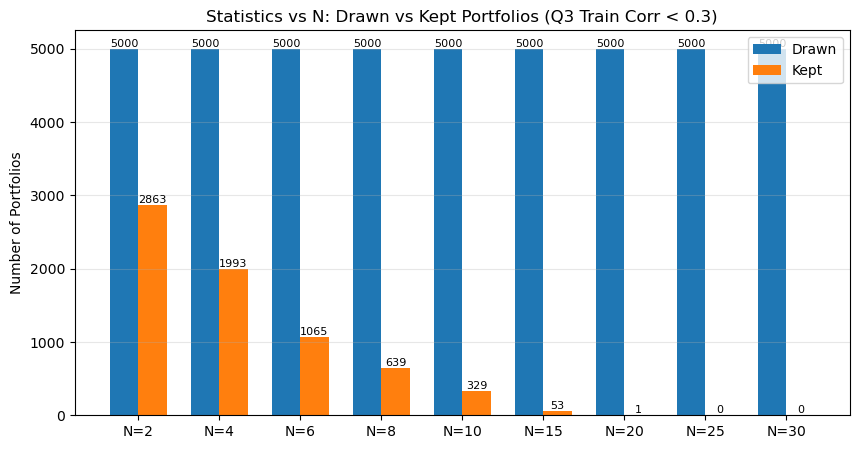

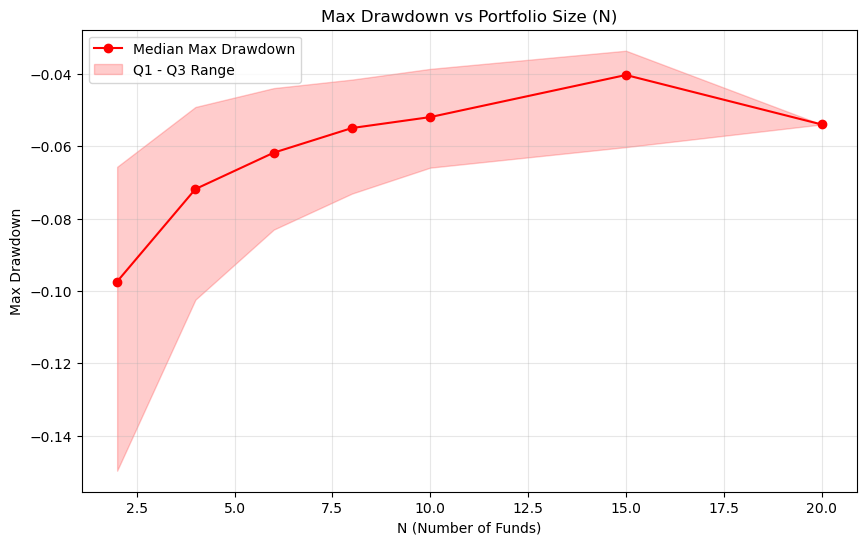

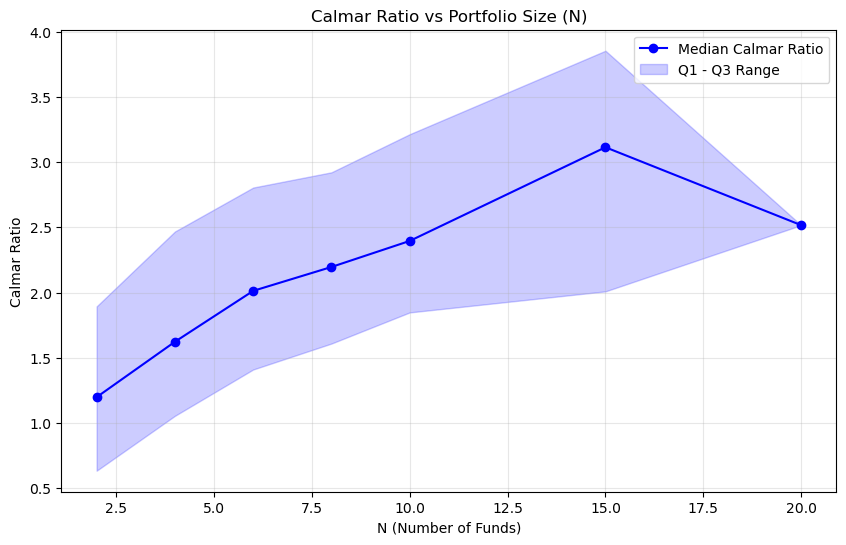

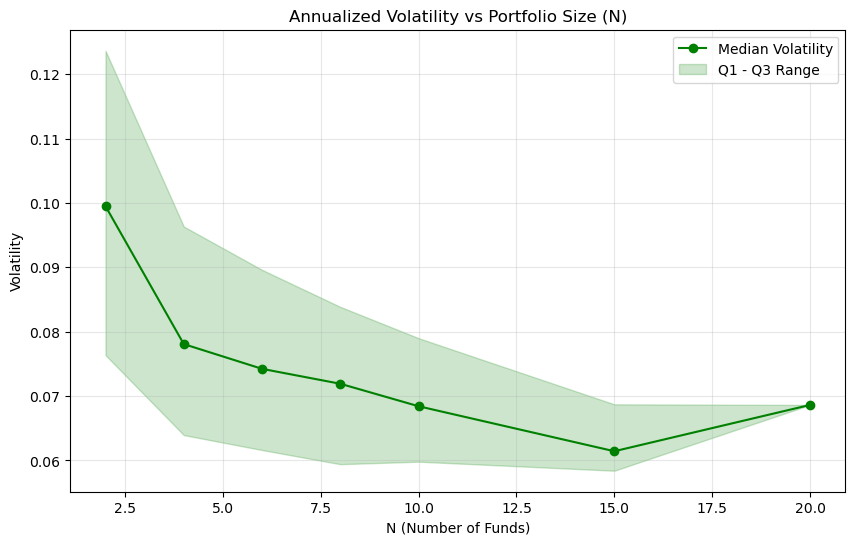

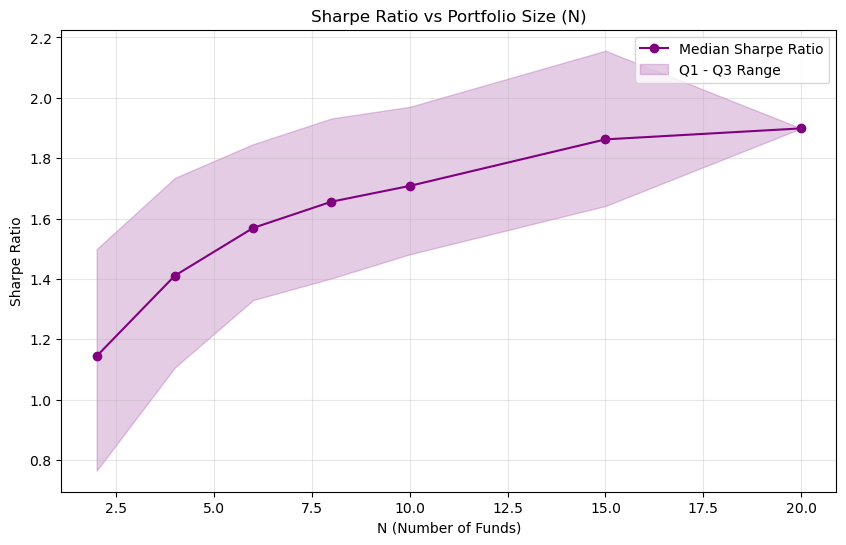

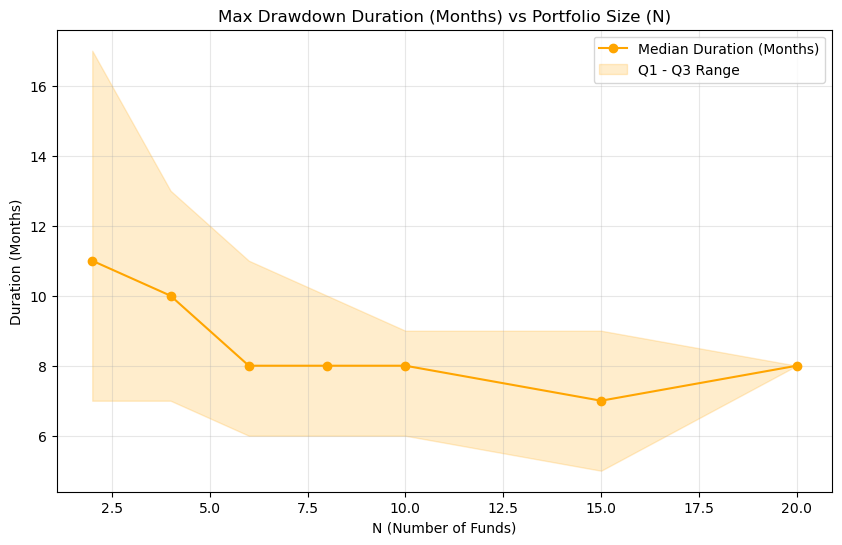

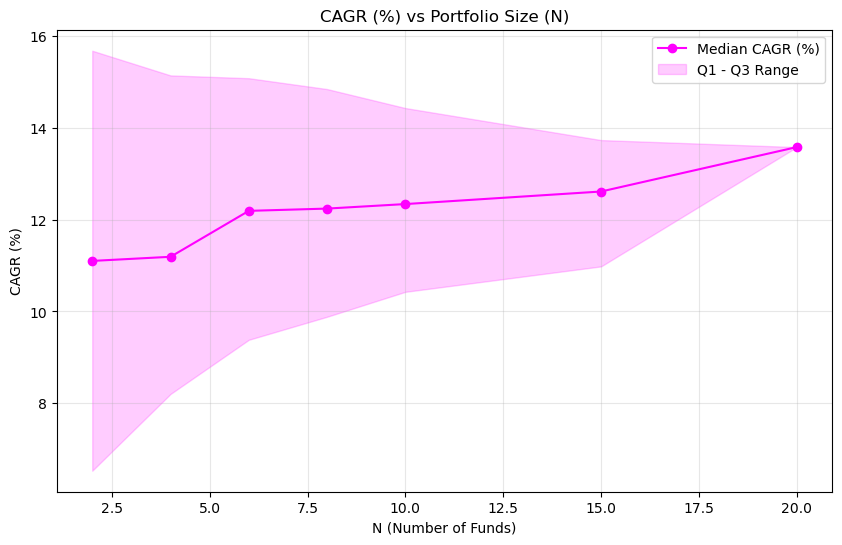

In [78]:
# Plotting Metrics vs N

# Plot Drawn vs Kept first
if len(drawn_stats_N) > 0:
    plt.figure(figsize=(10, 5))
    x_pos = np.arange(len(N_values))
    width = 0.35
    plt.bar(x_pos - width/2, drawn_stats_N, width, label='Drawn')
    plt.bar(x_pos + width/2, kept_stats_N, width, label='Kept')
    plt.xticks(x_pos, [f'N={n}' for n in N_values])
    plt.title('Statistics vs N: Drawn vs Kept Portfolios (Q3 Train Corr < 0.3)')
    plt.ylabel('Number of Portfolios')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    for i, (d, k) in enumerate(zip(drawn_stats_N, kept_stats_N)):
        plt.text(i - width/2, d, str(d), ha='center', va='bottom', fontsize=8)
        plt.text(i + width/2, k, str(k), ha='center', va='bottom', fontsize=8)
    plt.show()

if len(stats['mdd']['N']) > 0:
    metrics_info = [
        ('mdd', 'Max Drawdown vs Portfolio Size (N)', 'Max Drawdown', 'red'),
        ('calmar', 'Calmar Ratio vs Portfolio Size (N)', 'Calmar Ratio', 'blue'),
        ('vol', 'Annualized Volatility vs Portfolio Size (N)', 'Volatility', 'green'),
        ('sharpe', 'Sharpe Ratio vs Portfolio Size (N)', 'Sharpe Ratio', 'purple'),
        ('duration', 'Max Drawdown Duration (Months) vs Portfolio Size (N)', 'Duration (Months)', 'orange'),
        ('cagr', 'CAGR (%) vs Portfolio Size (N)', 'CAGR (%)', 'magenta')
    ]
    
    for key, title, ylabel, color in metrics_info:
        plt.figure(figsize=(10, 6))
        plt.plot(stats[key]['N'], stats[key]['median'], marker='o', label=f'Median {ylabel}', color=color)
        plt.fill_between(stats[key]['N'], stats[key]['q1'], stats[key]['q3'], color=color, alpha=0.2, label='Q1 - Q3 Range')
        plt.title(title)
        plt.xlabel('N (Number of Funds)')
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

else:
    print("Not enough funds for testing N_values.")
